In [2]:
from google.colab import files

uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape


(9994, 21)

In [5]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.dtypes


,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [7]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df[['Order Date', 'Ship Date']].dtypes)


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [12]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].dtypes


,0
Sales,float64
Quantity,int64
Discount,float64
Profit,float64


In [13]:
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Discount below 0:", (df['Discount'] < 0).sum())
print("Discount above 1:", (df['Discount'] > 1).sum())


Negative Sales: 0
Negative Quantity: 0
Discount below 0: 0
Discount above 1: 0


In [14]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100


In [15]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,11.25


In [16]:
df.shape


(9994, 25)

In [17]:
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']].describe()


,Sales,Quantity,Discount,Profit,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,12.031393
std,623.245101,2.225110,0.206452,234.260108,46.675435
min,0.444000,1.000000,0.000000,-6599.978000,-275.000000
25%,17.280000,2.000000,0.000000,1.728750,7.500000
50%,54.490000,3.000000,0.200000,8.666500,27.000000
75%,209.940000,5.000000,0.200000,29.364000,36.250000
max,22638.480000,14.000000,0.800000,8399.976000,50.000000


In [18]:
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")


Total Sales: $2,297,200.86


In [19]:
total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:,.2f}")


Total Profit: $286,397.02


In [20]:
total_quantity = df['Quantity'].sum()
print(f"Total Quantity Sold: {total_quantity:,}")


Total Quantity Sold: 37,873


In [21]:
total_orders = df['Order ID'].nunique()
print(f"Total Orders: {total_orders:,}")


Total Orders: 5,009


In [22]:
total_customers = df['Customer ID'].nunique()
print(f"Total Customers: {total_customers:,}")


Total Customers: 793


In [23]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales


,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [24]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit


,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


In [25]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales


,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


In [26]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_profit


,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


In [27]:
print("===== SALES BY CATEGORY =====")
print(category_sales)

print("\n===== PROFIT BY CATEGORY =====")
print(category_profit)

print("\n===== SALES BY REGION =====")
print(region_sales)

print("\n===== PROFIT BY REGION =====")
print(region_profit)


===== SALES BY CATEGORY =====
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

===== PROFIT BY CATEGORY =====
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

===== SALES BY REGION =====
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

===== PROFIT BY REGION =====
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [28]:
overall_profit_margin = (total_profit / total_sales) * 100

print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")


Overall Profit Margin: 12.47%


In [29]:
best_sales_category = category_sales.idxmax()
best_profit_category = category_profit.idxmax()

print("Highest Sales Category:", best_sales_category)
print("Highest Profit Category:", best_profit_category)


Highest Sales Category: Technology
Highest Profit Category: Technology


In [30]:
best_sales_region = region_sales.idxmax()
best_profit_region = region_profit.idxmax()

print("Highest Sales Region:", best_sales_region)
print("Highest Profit Region:", best_profit_region)


Highest Sales Region: West
Highest Profit Region: West


In [31]:
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

correlation


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


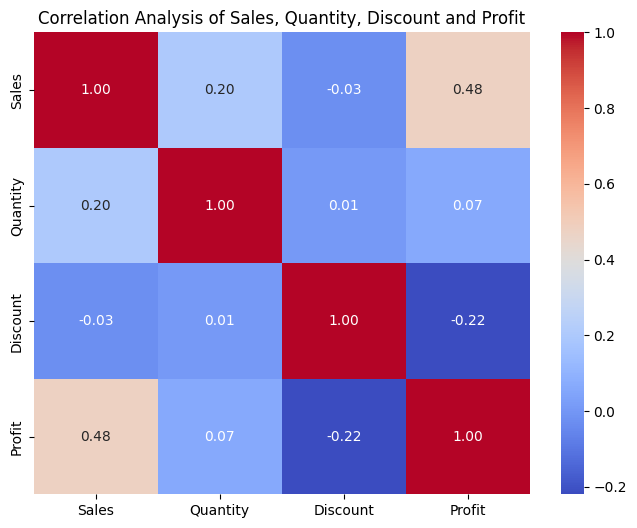

In [32]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Analysis of Sales, Quantity, Discount and Profit')
plt.show()


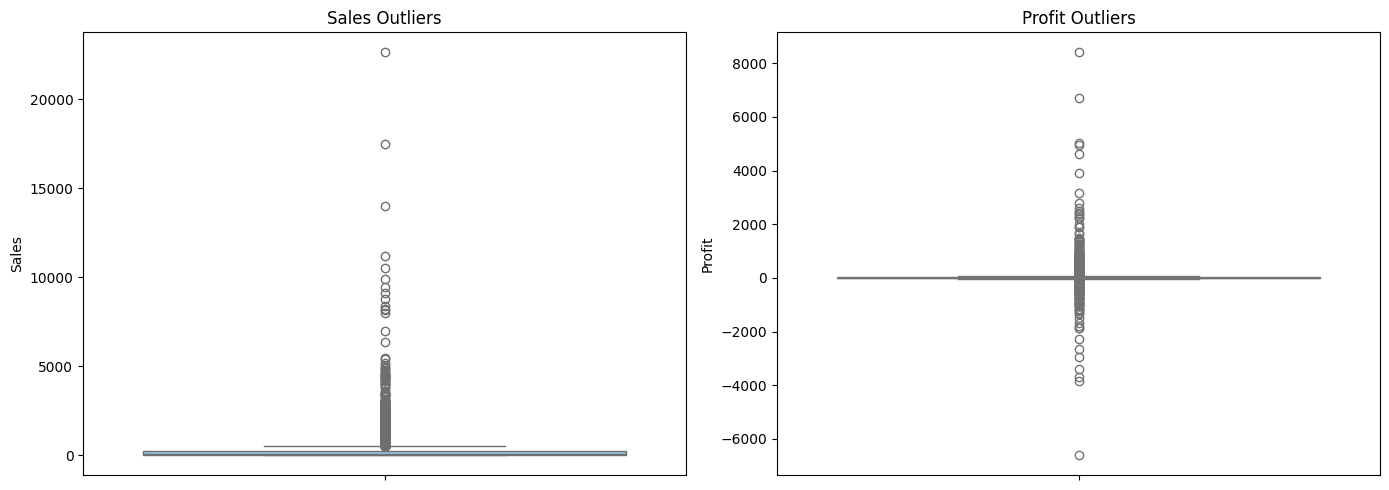

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Sales Outliers')
axes[0].set_ylabel('Sales')

sns.boxplot(y=df['Profit'], ax=axes[1], color='lightgreen')
axes[1].set_title('Profit Outliers')
axes[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()


In [34]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales


,Sales
Order Date,
2014-01,14236.8950
2014-02,4519.8920
2014-03,55691.0090
2014-04,28295.3450
2014-05,23648.2870
2014-06,34595.1276
2014-07,33946.3930
2014-08,27909.4685
2014-09,81777.3508


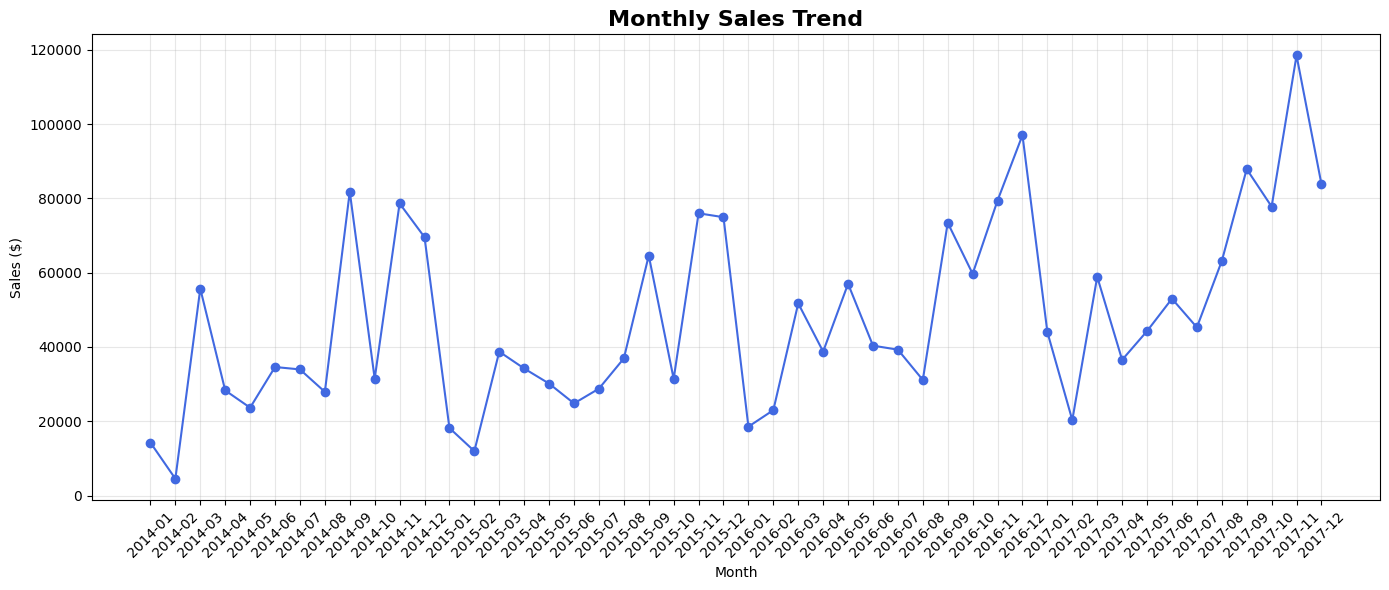

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o',
    color='royalblue'
)

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


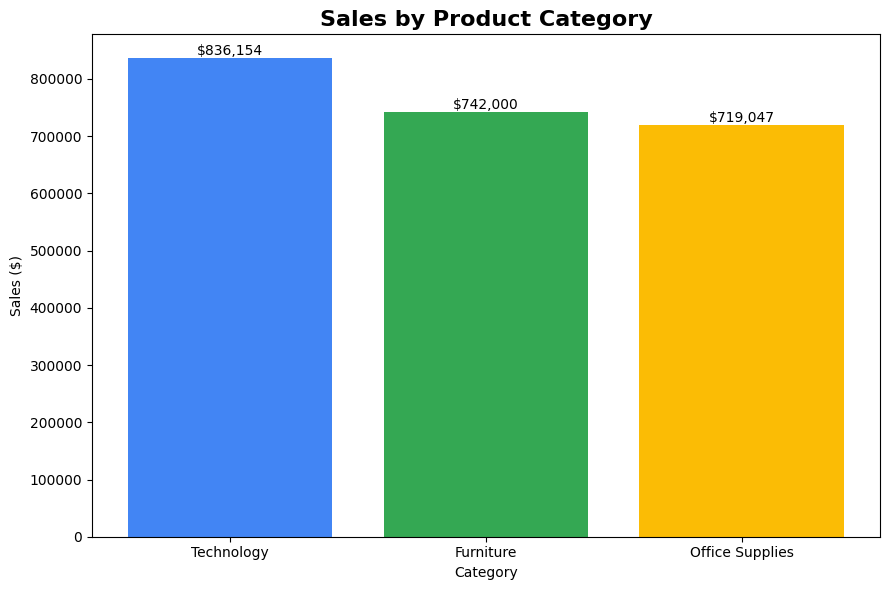

In [36]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    category_sales.index,
    category_sales.values,
    color=['#4285F4', '#34A853', '#FBBC05']
)

plt.title('Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Sales ($)')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


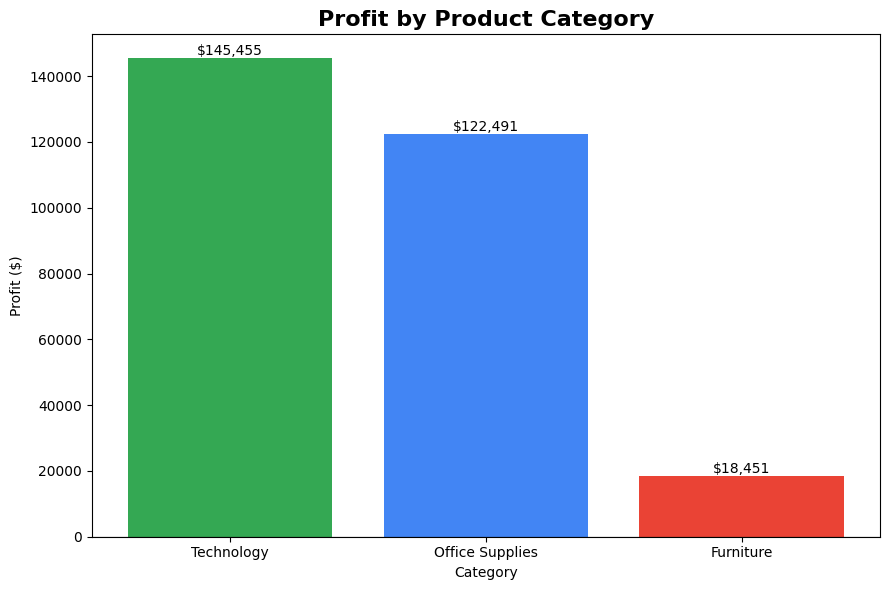

In [37]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    category_profit.index,
    category_profit.values,
    color=['#34A853', '#4285F4', '#EA4335']
)

plt.title('Profit by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Profit ($)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


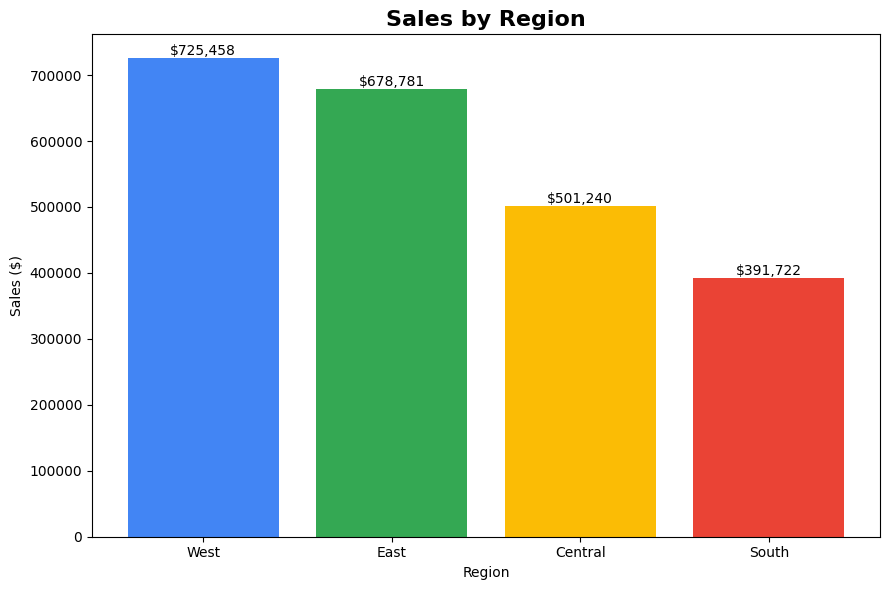

In [38]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    region_sales.index,
    region_sales.values,
    color=['#4285F4', '#34A853', '#FBBC05', '#EA4335']
)

plt.title('Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Sales ($)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


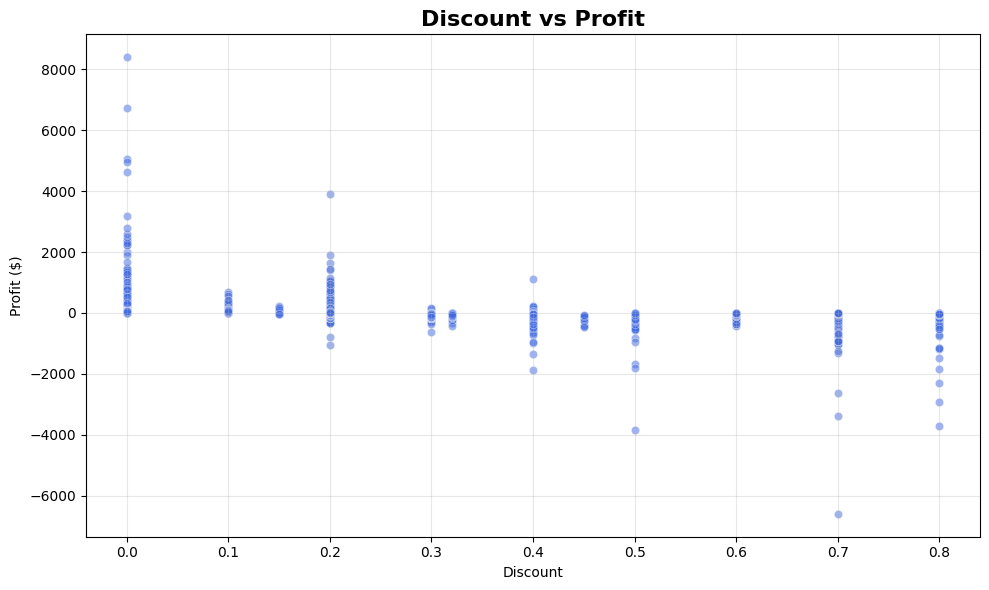

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.5,
    color='royalblue'
)

plt.title('Discount vs Profit', fontsize=16, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


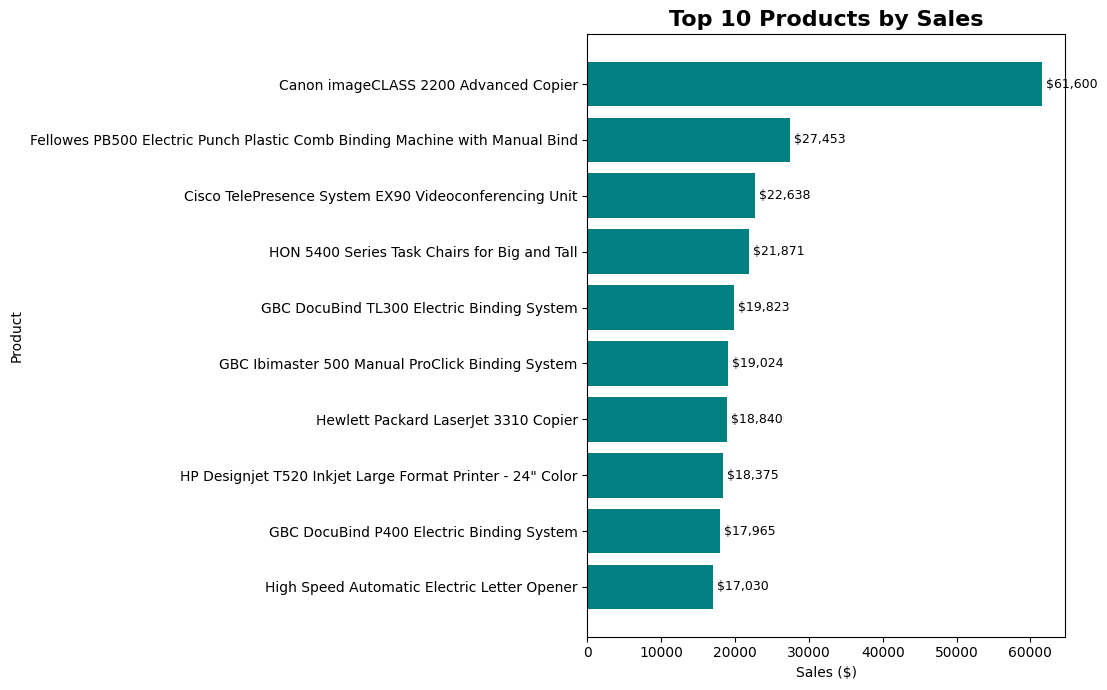

In [40]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_products.index,
    top_products.values,
    color='teal'
)

plt.title(
    'Top 10 Products by Sales',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sales ($)')
plt.ylabel('Product')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f' ${width:,.0f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [41]:
subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print("Top 5 Sub-Categories by Profit:")
print(subcategory_profit.head(5))

print("\nBottom 5 Sub-Categories by Profit:")
print(subcategory_profit.tail(5))


Top 5 Sub-Categories by Profit:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64

Bottom 5 Sub-Categories by Profit:
Sub-Category
Machines      3384.7569
Fasteners      949.5182
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64


In [42]:
region_category_profit = (
    df.groupby(['Region', 'Category'])['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(region_category_profit.head(10))


Region   Category       
West     Office Supplies    52609.8490
East     Technology         47462.0351
West     Technology         44303.6496
East     Office Supplies    41014.5791
Central  Technology         33697.4320
South    Technology         19991.8314
         Office Supplies    19986.3928
West     Furniture          11504.9503
Central  Office Supplies     8879.9799
South    Furniture           6771.2061
Name: Profit, dtype: float64


In [43]:
discount_analysis = (
    df.groupby('Discount')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .sort_index()
)

discount_analysis


,Sales,Profit,Quantity
Discount,,,
0.00,1.087908e+06,320987.6032,18267
0.10,5.436935e+04,9029.1770,373
0.15,2.755852e+04,1418.9915,198
0.20,7.645944e+05,90337.3060,13660
0.30,1.032267e+05,-10369.2774,849
0.32,1.449346e+04,-2391.1377,105
0.40,1.164178e+05,-23057.0504,786
0.45,5.484974e+03,-2493.1111,45
0.50,5.891854e+04,-20506.4281,241


In [44]:
loss_records = (df['Profit'] < 0).sum()

print(f"Loss-making records: {loss_records}")
print(f"Percentage of loss-making records: {(loss_records / len(df)) * 100:.2f}%")


Loss-making records: 1871
Percentage of loss-making records: 18.72%


In [45]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Best Sales Month:", best_month)
print(f"Sales: ${best_month_sales:,.2f}")


Best Sales Month: 2017-11
Sales: $118,447.82


In [46]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Rows: 9994
Columns: 25

Missing values:
0

Duplicate rows:
0


In [47]:
df.to_csv('/content/Superstore_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [48]:
from google.colab import files

files.download('/content/Superstore_Cleaned.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
print("===== OVERALL PERFORMANCE =====")

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_quantity = df["Quantity"].sum()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Profit Margin: {profit_margin:.2f}%")


===== OVERALL PERFORMANCE =====
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Total Quantity: 37,873
Profit Margin: 12.47%


In [50]:
category_results = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Sales", ascending=False)
)

display(category_results)

print("Highest Sales Category:",
      category_results["Sales"].idxmax())

print("Highest Profit Category:",
      category_results["Profit"].idxmax())


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


Highest Sales Category: Technology
Highest Profit Category: Technology


In [51]:
region_results = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit", ascending=False)
)

display(region_results)

print("Most Profitable Region:",
      region_results["Profit"].idxmax())

print("Least Profitable Region:",
      region_results["Profit"].idxmin())


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


Most Profitable Region: West
Least Profitable Region: Central


In [52]:
subcat_results = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit", ascending=False)
)

display(subcat_results)

print("Most Profitable Sub-Category:",
      subcat_results["Profit"].idxmax())

print("Least Profitable Sub-Category:",
      subcat_results["Profit"].idxmin())


,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


Most Profitable Sub-Category: Copiers
Least Profitable Sub-Category: Tables


In [53]:
segment_results = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

display(segment_results)

print("Highest Sales Segment:",
      segment_results["Sales"].idxmax())


,Sales,Profit,Orders,Customers
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,409
Corporate,7.061464e+05,91979.1340,1514,236
Home Office,4.296531e+05,60298.6785,909,148


Highest Sales Segment: Consumer


In [54]:
year_results = (
    df.groupby("Year")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

display(year_results)

print("Highest Sales Year:",
      year_results["Sales"].idxmax())


,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


Highest Sales Year: 2017


In [55]:
discount_profit_corr = df["Discount"].corr(df["Profit"])

print(
    f"Discount vs Profit Correlation: "
    f"{discount_profit_corr:.3f}"
)


Discount vs Profit Correlation: -0.219


In [56]:
# ===== TASK 7: BUSINESS INSIGHT SUMMARY =====

# Category
category_results = (
    df.groupby("Category")
      .agg(Sales=("Sales", "sum"),
           Profit=("Profit", "sum"))
      .sort_values("Sales", ascending=False)
)

# Region
region_results = (
    df.groupby("Region")
      .agg(Sales=("Sales", "sum"),
           Profit=("Profit", "sum"))
      .sort_values("Profit", ascending=False)
)

# Sub-category
subcat_results = (
    df.groupby("Sub-Category")
      .agg(Sales=("Sales", "sum"),
           Profit=("Profit", "sum"))
      .sort_values("Profit", ascending=False)
)

# Segment
segment_results = (
    df.groupby("Segment")
      .agg(Sales=("Sales", "sum"),
           Profit=("Profit", "sum"))
      .sort_values("Sales", ascending=False)
)

# Year
year_results = (
    df.groupby("Year")
      .agg(Sales=("Sales", "sum"),
           Profit=("Profit", "sum"))
      .sort_values("Sales", ascending=False)
)

print("===== CATEGORY =====")
print(category_results.round(2))

print("\n===== REGION =====")
print(region_results.round(2))

print("\n===== TOP 5 PROFITABLE SUB-CATEGORIES =====")
print(subcat_results.head(5).round(2))

print("\n===== BOTTOM 5 PROFITABLE SUB-CATEGORIES =====")
print(subcat_results.tail(5).round(2))

print("\n===== CUSTOMER SEGMENT =====")
print(segment_results.round(2))

print("\n===== YEAR =====")
print(year_results.round(2))

print("\n===== DISCOUNT VS PROFIT =====")
print(f"Correlation: {df['Discount'].corr(df['Profit']):.3f}")


===== CATEGORY =====
                     Sales     Profit
Category                             
Technology       836154.03  145454.95
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80

===== REGION =====
             Sales     Profit
Region                       
West     725457.82  108418.45
East     678781.24   91522.78
South    391721.90   46749.43
Central  501239.89   39706.36

===== TOP 5 PROFITABLE SUB-CATEGORIES =====
                  Sales    Profit
Sub-Category                     
Copiers       149528.03  55617.82
Phones        330007.05  44515.73
Accessories   167380.32  41936.64
Paper          78479.21  34053.57
Binders       203412.73  30221.76

===== BOTTOM 5 PROFITABLE SUB-CATEGORIES =====
                  Sales    Profit
Sub-Category                     
Machines      189238.63   3384.76
Fasteners       3024.28    949.52
Supplies       46673.54  -1189.10
Bookcases     114880.00  -3472.56
Tables        206965.53 -17725.48

===== CUSTOMER SEGM

Business Insights & Recommendations
Business Insights
1. Technology is the strongest category

Technology generated the highest sales of $836,154.03 and the highest profit of $145,454.95 among the three categories. This makes Technology the strongest overall product category and an important contributor to the company's financial performance.

2. The West region is the top-performing region

The West region generated the highest sales of $725,457.82 and the highest profit of $108,418.45. In comparison, the Central region generated the lowest profit at $39,706.36. This indicates a significant difference in profitability across geographic regions.

3. Copiers are the most profitable sub-category

Copiers generated the highest profit among all sub-categories, with $55,617.82 in profit from $149,528.03 in sales. Phones and Accessories were also strong contributors, generating $44,515.73 and $41,936.64 in profit respectively.

4. Tables are the weakest sub-category

Tables generated $206,965.53 in sales but produced a loss of $17,725.48, making it the weakest sub-category by profitability. Bookcases also generated a loss of $3,472.56. This shows that high sales volume does not necessarily translate into high profitability.

5. Consumer customers are the largest segment

The Consumer segment generated the highest sales at $1,161,401.34 and the highest profit at $134,119.21. Corporate customers generated $706,146.37 in sales and $91,979.13 in profit, while Home Office generated $429,653.15 in sales and $60,298.68 in profit.

6. Sales increased strongly by 2017

The highest annual sales were recorded in 2017, reaching $733,215.26, compared with $609,205.60 in 2016. This indicates strong overall sales growth over the later years of the dataset.

7. Discounts have a weak negative relationship with profit

The correlation between Discount and Profit is -0.219, indicating a weak negative relationship. This suggests that higher discount levels are generally associated with lower profit in the dataset. However, correlation does not establish that discounts directly cause lower profits, so the relationship should be investigated further.

Business Recommendations
Recommendation 1 — Review pricing and discounts for low-profit products

Management should review discount levels, pricing and costs for low-profit sub-categories, particularly Tables and Bookcases. Reducing excessive discounts or improving pricing and cost management could help improve their profitability.

Recommendation 2 — Invest in high-performing categories and products

The company should continue supporting high-performing areas such as Technology, Copiers, Phones, and Accessories. Marketing campaigns, inventory availability and sales efforts can be prioritized toward products that consistently generate strong profits.

Recommendation 3 — Improve performance in weaker regions

The Central region should be investigated because it generated the lowest regional profit at $39,706.36. Management should examine product mix, discount levels, pricing, customer demand and operating costs in this region to identify opportunities for improvement.

Conclusion

The analysis shows that the Superstore business generated $2.30 million in sales and $286,397.02 in profit, resulting in an overall profit margin of 12.47%. Technology was the strongest category, the West was the strongest region, and the Consumer segment was the largest contributor to sales and profit.

At the same time, certain sub-categories such as Tables and Bookcases generated losses despite having substantial sales. The negative relationship between discounts and profit also highlights the importance of carefully managing promotional strategies.

Overall, the findings demonstrate that analyzing sales together with profitability provides more useful business information than focusing on revenue alone. The recommendations therefore focus on improving low-profit areas while continuing to invest in strong-performing categories, products and regions.